In [85]:
import random

Setup:
- N objects
- N sets with i random objects
- N costs associated to the i sets
- penalty weight > sum of all costs

In [86]:
N = 100
random.seed(42)

OBJECTS = {n for n in range(N)}
SETS = tuple(frozenset(random.sample(range(N), k=s+1)) for s in range(N))
COSTS = tuple(10*random.random()+(s*random.random())**2 for s in range(N))

PENALTY_WEIGHT = sum(COSTS) + 1

In [87]:
OBJECTS, SETS, COSTS

({0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99},
 (frozenset({81}),
  frozenset({3, 14}),
  frozenset({31, 35, 94}),
  frozenset({13, 17, 28, 94}),
  frozenset({11, 69, 75, 86, 94}),
  frozenset({3, 4, 11, 27, 29, 54}),
  frozenset({3, 25, 64, 71, 77, 83, 91}),
  frozenset({0, 28, 35, 53, 57, 69, 75, 89}),
  frozenset({13, 19, 20, 27, 35, 43, 54, 89, 97}),
  frozenset({5, 11, 12, 33, 44, 45, 48, 58, 77, 93}),
  frozenset({10, 15, 24, 37, 46, 48, 68, 70, 

- The penalty depends on the number of missing objects
- Computing the current state is_valid is crucial to check if the solution is valid

In [88]:
def fitness(state):
    """
    state: tuple or list of booleans of N elements
    return: fitness value -> (total_cost + penalty) and if it is a valid state
    """
    total_cost = 0.0
    covered = set()

    for i, selected in enumerate(state):
        if selected:
            total_cost += COSTS[i]
            covered.update(SETS[i])

    uncovered_count = len(OBJECTS - covered)
    penalty = uncovered_count * PENALTY_WEIGHT

    return -(total_cost + penalty), uncovered_count == 0

In [89]:
def tweak(state):
    """
    Flip a random position, based on boolean values
    """
    new_state = list(state)
    flip_i = random.randrange(len(state))
    new_state[flip_i] = not new_state[flip_i]

    return tuple(new_state)

In [90]:
def hill_climbing(current_state, max_evals_without_improvement=100000):
    current_fit, current_valid = fitness(current_state)

    history = list()
    history.append(current_fit)

    evals = 0
    failed_steps = 0

    while failed_steps < max_evals_without_improvement:
        evals += 1
        new_state = tweak(current_state)
        new_fit, new_valid = fitness(new_state)

        if new_fit > current_fit:
            history.append(new_fit)
            current_state = new_state
            current_fit = new_fit
            current_valid = new_valid
            failed_steps = 0
            print(evals, current_state, current_fit)
        else:
            failed_steps += 1

    return current_state, current_fit, current_valid, evals, history

### Test with a random solution as a tuple of booleans, each boolen rapresent a set, the tweak only swap 1 set at time

In [91]:
current_state = tuple(random.choice([True, False]) for _ in range(N))
best_state, best_fit, is_valid, total_evals, history = hill_climbing(current_state)

if is_valid:
    print(f"Best sol: {best_state}")
    print(f"Best fit: {-sum(c for s, c in zip(best_state, COSTS) if s):.4f}")

1 (True, True, True, True, True, True, True, True, False, True, False, True, False, True, True, False, False, False, True, True, False, True, True, False, True, False, False, False, True, False, False, True, True, True, True, False, True, True, True, False, True, True, True, False, True, True, False, False, False, True, False, True, False, False, False, True, False, True, False, False, True, True, False, False, False, True, True, True, True, True, False, True, False, False, False, True, True, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, True, True, True, False, True, True) -35044.42418475033
2 (True, True, True, True, True, True, True, True, False, True, False, True, False, True, True, False, False, False, True, True, False, True, True, False, True, False, False, False, True, False, False, True, True, True, True, False, True, True, True, False, True, True, True, False, True, True, False, False, False, True, False, 

Last check for best_state dimensionality, we expect d_best_state = N

In [92]:
covered_elements = set().union(*(s for s, selected in zip(SETS, best_state) if selected))
len(covered_elements)

100

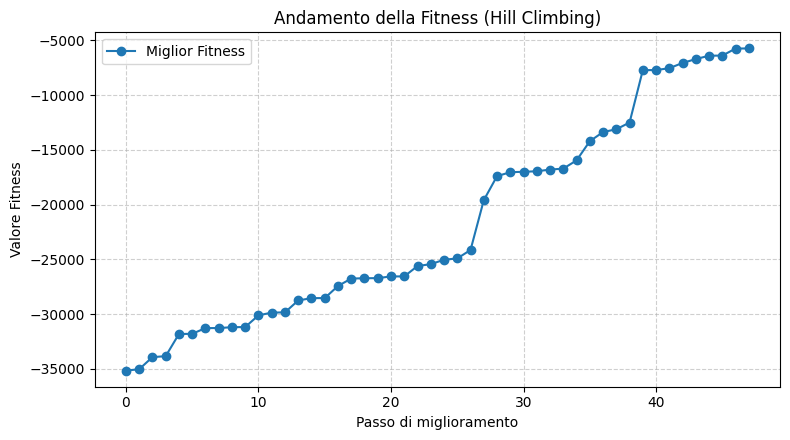

In [93]:
from itertools import accumulate

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(
    range(len(history)),
    list(accumulate(history, max)),
    marker="o",
    linestyle="-",
    color="tab:blue",
    label="Miglior Fitness",
)

plt.title("Andamento della Fitness (Hill Climbing)")
plt.xlabel("Passo di miglioramento")
plt.ylabel("Valore Fitness")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

### Test with a more powerful tweak

In [94]:
def tweak_with_swap(state, p_swap=0.3):
    new_state = list(state)
    if random.random() < p_swap:
        trues = [i for i, v in enumerate(new_state) if v]
        falses = [i for i, v in enumerate(new_state) if not v]
        if trues and falses:
            new_state[random.choice(trues)] = False
            new_state[random.choice(falses)] = True
            return tuple(new_state)
        
    idx = random.randrange(len(state))
    new_state[idx] = not new_state[idx]
    return tuple(new_state)

In [95]:
def hill_climbing(current_state, max_evals_without_improvement=100000):
    current_fit, current_valid = fitness(current_state)

    history = list()
    history.append(current_fit)

    evals = 0
    failed_steps = 0

    while failed_steps < max_evals_without_improvement:
        evals += 1
        new_state = tweak_with_swap(current_state)
        new_fit, new_valid = fitness(new_state)

        if new_fit > current_fit:
            history.append(new_fit)
            current_state = new_state
            current_fit = new_fit
            current_valid = new_valid
            failed_steps = 0
            print(evals, current_state, current_fit)
        else:
            failed_steps += 1

    return current_state, current_fit, current_valid, evals, history

In [96]:
current_state = tuple(random.choice([True, False]) for _ in range(N))
best_state, best_fit, is_valid, total_evals, history = hill_climbing(current_state)

if is_valid:
    print(f"Best sol: {best_state}")
    print(f"Best fit: {-sum(c for s, c in zip(best_state, COSTS) if s):.4f}")

covered_elements = set().union(*(s for s, selected in zip(SETS, best_state) if selected))
len(covered_elements)

1 (True, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, True, True, False, True, True, False, False, True, True, False, True, True, True, True, True, True, False, False, False, False, False, False, True, True, False, True, False, True, False, False, False, False, True, False, False, False, False, False, True, False, False, True, False, False, False, True, False, True, False, True, False, False, True, True, True, True, True, True, False, True, False, True, True, True, False, False, True, True, True, True, True, True, False, True, True, False, True, False, True, False, True, False, True, True) -54872.35915894636
2 (True, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, True, True, False, True, True, False, False, True, True, False, True, True, True, True, True, True, False, False, False, False, False, False, False, True, False, True, False, True, False, False, False, False, True, F

100

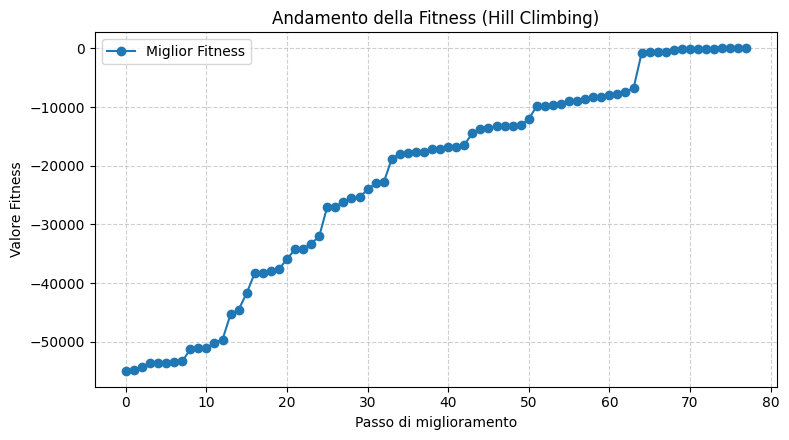

In [97]:
from itertools import accumulate

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(
    range(len(history)),
    list(accumulate(history, max)),
    marker="o",
    linestyle="-",
    color="tab:blue",
    label="Miglior Fitness",
)

plt.title("Andamento della Fitness (Hill Climbing)")
plt.xlabel("Passo di miglioramento")
plt.ylabel("Valore Fitness")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()